In [1]:

from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from datasets import load_from_disk, DatasetDict
from qwen_vl_utils import process_vision_info
import os
import torch
import torch.nn.functional as F

import dotenv
dotenv.load_dotenv()

True

In [2]:
REASONING_MODEL = 'Jakh0103/Qwen2.5-VL-3B-GRPO-VSR'
PAD_LENGHT = 800

ORIGINAL_DATASET_PATH =  os.environ['DATA_PATH'] + "/vsr"
OUTPUT_DATASET_PATH =  os.environ['DATA_PATH'] + "/vsr_prompt_tuning"

# default: Load the model on the available device(s)
reasoning_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    REASONING_MODEL, torch_dtype="auto", device_map="cuda:0"
)

# default processor
processor = AutoProcessor.from_pretrained(REASONING_MODEL, use_fast=True)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [3]:
# preprocess the dataset
dataset = load_from_disk(ORIGINAL_DATASET_PATH)

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['caption', 'label', 'relation', 'subj', 'obj', 'image_path'],
        num_rows: 3489
    })
    validation: Dataset({
        features: ['caption', 'label', 'relation', 'subj', 'obj', 'image_path'],
        num_rows: 340
    })
    test: Dataset({
        features: ['caption', 'label', 'relation', 'subj', 'obj', 'image_path'],
        num_rows: 1222
    })
})

In [ ]:
NUM_SAMPLES = {'train': 1000, 'validation': 10, 'test': 10}
dataset = {k: v.select(range(NUM_SAMPLES[k])) for k, v in dataset.items()}



In [6]:
dataset = {
    k: di.map(
        lambda sample: {
            "problem": f'Is the following statement true: {sample["caption"]}',
            "solution": str(sample["label"] == 1),
        },
        remove_columns=["caption", "label", "relation", "subj", "obj"],
        desc="Preprocessing dataset",
    )
    for k, di in dataset.items()
}



Preprocessing dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

In [7]:
def make_conversation_from_prompt(example, prompt_template, answer = None):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": f"file://{example['image_path']}"},
                {"type": "text", "text": prompt_template(example)},
            ],
        }
    ]
    if answer is not None:
        messages.append(
            {
                "role": "assistant",
                "content": [
                    {"type": "text", "text": answer},
                ],
            }
        )
    return {"messages": messages, "solution": example['solution']}

# apply formatting
def reasoning_prompt_template(example):
    return f"{example['problem']} First output the thinking process in <think> </think> tags and then output the final answer in <answer> </answer> tags."

def baseline_prompt_template(example):
    return f"{example['problem']} First output the thinking process in <think> </think> tags and then output the final answer in <answer> </answer> tags."


In [8]:
from trl.trainer.utils import pad


TH_TOKEN_ID = processor.tokenizer.convert_tokens_to_ids("<th")

def add_reasoning_output(item):
    conversation = make_conversation_from_prompt(item, reasoning_prompt_template)

    text = processor.apply_chat_template(
        conversation['messages'], tokenize=False, add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(conversation['messages'])

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = inputs.to(reasoning_model.device)


    # Inference: Generation of the output
    with torch.no_grad():
        # Generate the output
        generated_ids = reasoning_model.generate(**inputs, max_new_tokens=256)
        generated_ids_trimmed = [
            out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]
        output_text_batch = processor.batch_decode(
            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )
        assert len(output_text_batch) == 1
        output_text = output_text_batch[0]
    
    training_conversation = make_conversation_from_prompt(item, baseline_prompt_template, output_text)
    training_text = processor.apply_chat_template(
        training_conversation['messages'], tokenize=False, add_generation_prompt=False
    )
    training_inputs = processor(
        text=[training_text],
        images=image_inputs,
        videos=video_inputs,
        padding="max_length",
        truncation=True,
        max_length=PAD_LENGHT,
        return_tensors="pt",
    )
    reasoning_token_indexes = (training_inputs.input_ids[0] == TH_TOKEN_ID).nonzero().flatten().tolist()
    assert len(reasoning_token_indexes) == 1
    reasoning_offset = reasoning_token_indexes[0]

    with torch.no_grad():
        output = reasoning_model(
            **training_inputs.to(reasoning_model.device),
            return_dict=True,
        )





    return {
        "desired_output": output_text,
        "training_inputs": {k: v.cpu() for k, v in training_inputs.items()},
        "reasoning_logits_offset": reasoning_offset,
        "reasoning_logits": output.logits[0, :].cpu(),
    }

item = dataset['train'][8]
r = add_reasoning_output(item)

In [ ]:
# r['training_inputs']['input_ids'].shape, r['reasoning_logits_offset'], r['reasoning_logits'].shape, r['desired_output']

: 

In [ ]:
dataset = {k: v.map(add_reasoning_output) for k, v in dataset.items()}

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [ ]:
dataset

{'train': Dataset({
     features: ['image_path', 'problem', 'solution', 'desired_output', 'training_inputs', 'reasoning_logits_offset', 'reasoning_logits'],
     num_rows: 10
 }),
 'validation': Dataset({
     features: ['image_path', 'problem', 'solution', 'desired_output', 'training_inputs', 'reasoning_logits_offset', 'reasoning_logits'],
     num_rows: 10
 }),
 'test': Dataset({
     features: ['image_path', 'problem', 'solution', 'desired_output', 'training_inputs', 'reasoning_logits_offset', 'reasoning_logits'],
     num_rows: 10
 })}

In [ ]:
DatasetDict(dataset).save_to_disk(OUTPUT_DATASET_PATH)

Saving the dataset (0/6 shards):   0%|          | 0/10 [00:00<?, ? examples/s]

Saving the dataset (0/6 shards):   0%|          | 0/10 [00:00<?, ? examples/s]

Saving the dataset (0/6 shards):   0%|          | 0/10 [00:00<?, ? examples/s]

In [3]:
done_dataset = load_from_disk(OUTPUT_DATASET_PATH)
train = done_dataset['train']
print(len(train))

10


In [4]:
lengths = [len(processor.tokenizer.tokenize(do)) for do in train['desired_output']]

(array([1., 0., 0., 0., 0., 2., 0., 0., 2., 0., 0., 1., 0., 0., 3., 0., 0.,
        0., 0., 1.]),
 array([39.  , 40.35, 41.7 , 43.05, 44.4 , 45.75, 47.1 , 48.45, 49.8 ,
        51.15, 52.5 , 53.85, 55.2 , 56.55, 57.9 , 59.25, 60.6 , 61.95,
        63.3 , 64.65, 66.  ]),
 <BarContainer object of 20 artists>)

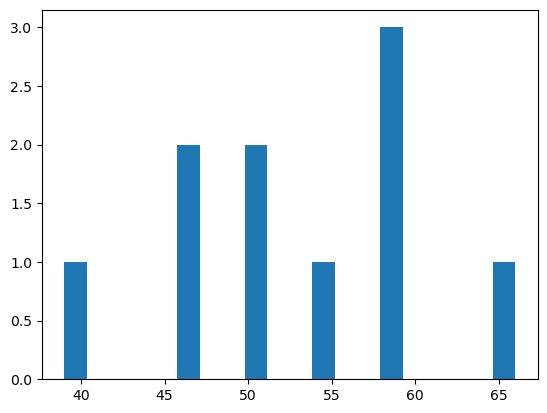

In [5]:
import matplotlib.pyplot as plt
plt.hist(lengths, bins=20)


{'whiskers': [<matplotlib.lines.Line2D at 0x7f26f8d68400>,
 'caps': [<matplotlib.lines.Line2D at 0x7f26f8b8fb50>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f26f8d6ad70>],
 'medians': [<matplotlib.lines.Line2D at 0x7f26f8bc0190>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f26f8bc0490>],
 'means': []}

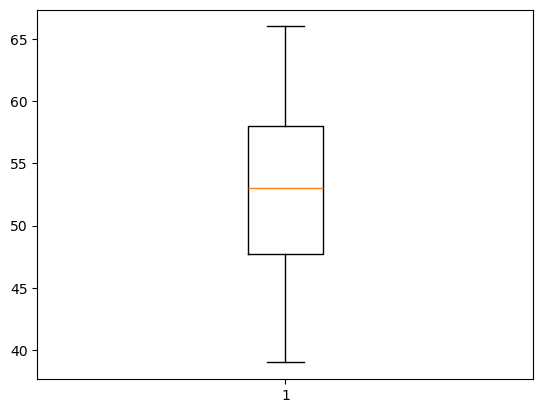

In [6]:
plt.boxplot(lengths)

In [7]:
for e in train:
    pass

In [9]:
item = train[0]

In [10]:
import sys
sys.getsizeof(item)

360

In [ ]:
from pympler import asizeof
print(asizeof.asizeof(item))  # includes nested objects

NameError: name 'asizeofy' is not defined

In [14]:
def viz_sizes(data):
    sizes = {k: asizeof.asizeof(v) for k, v in data.items()}

    # Sort and print nicely
    for k, size in sorted(sizes.items(), key=lambda x: -x[1]):
        print(f"{k}: {size / 1024:.2f} KB")
viz_sizes(item)

reasoning_logits: 4800875.54 KB
training_inputs: 79059.66 KB
desired_output: 0.30 KB
problem: 0.12 KB
image_path: 0.11 KB
solution: 0.05 KB
reasoning_logits_offset: 0.03 KB


In [15]:
tokenizer = processor.tokenizer
# Print vocab size
print("Vocab size:", tokenizer.vocab_size)

Vocab size: 151643


In [18]:
len(item['reasoning_logits'][0])

151936

In [19]:
item['reasoning_logits'][0][0]

np.float16(9.88)

In [23]:

print(asizeof.asizeof(item['reasoning_logits'][0][0]))  # includes nested objects

48
